# ListIQ — Pricing Prediction Model (Sprint 3)

**Goal:** Build a unified pricing model that predicts `final_sale_price` given item features (category, brand, condition, platform, title). This enables cross-platform price comparison for Sprint 4's routing algorithm.

**Architecture:** One XGBoost regression model with `platform` as a feature, trained on `log1p(final_sale_price)`.

**Key caveats:**
- Depop `final_sale_price` is the **listed** price, not a confirmed sold price — all Depop predictions are listed-price proxies
- eBay dominates volume (66% of data) — per-platform parity is evaluated explicitly
- 5,919 rows total — some platform×category cells are thin (Depop handbag: 69 items)

## Section 0: Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error
import xgboost as xgb
import joblib

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 150

FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)


def save_fig(name, fig=None):
    """Save current figure to figures/ as PNG and display inline."""
    target = fig or plt.gcf()
    target.savefig(FIGURES_DIR / f"{name}.png", bbox_inches="tight", facecolor="white")
    plt.show()


def median_ape(y_true, y_pred):
    """Median Absolute Percentage Error."""
    return np.median(np.abs((y_true - y_pred) / y_true)) * 100

## Section 1: Data Loading & Target Analysis

In [2]:
raw = pd.read_csv("../data/cleaned/all_platforms.csv")
print(f"Loaded {len(raw)} rows x {raw.shape[1]} columns")

# Drop columns unusable for modeling
DROP_COLS = [
    "price_tier", "price_discount_pct",        # derived from target (leakage)
    "original_list_price", "days_to_sale",       # 60-83% null
    "listing_day_of_week", "listing_time",       # 66% null (eBay only)
    "image_url", "item_id", "days_to_sale_outlier",  # non-features
    "sold_date",                                  # 14% null (all Depop), no temporal features
]
df = raw.drop(columns=DROP_COLS)
print(f"After dropping unusable columns: {df.shape[1]} columns remaining")
print(f"Columns: {list(df.columns)}")
print(f"\nNull check:")
print(df.isnull().sum().to_string())

Loaded 5919 rows x 16 columns
After dropping unusable columns: 6 columns remaining
Columns: ['platform', 'item_category', 'brand', 'condition', 'final_sale_price', 'title']

Null check:
platform              0
item_category         0
brand               199
condition             0
final_sale_price      0
title                 0


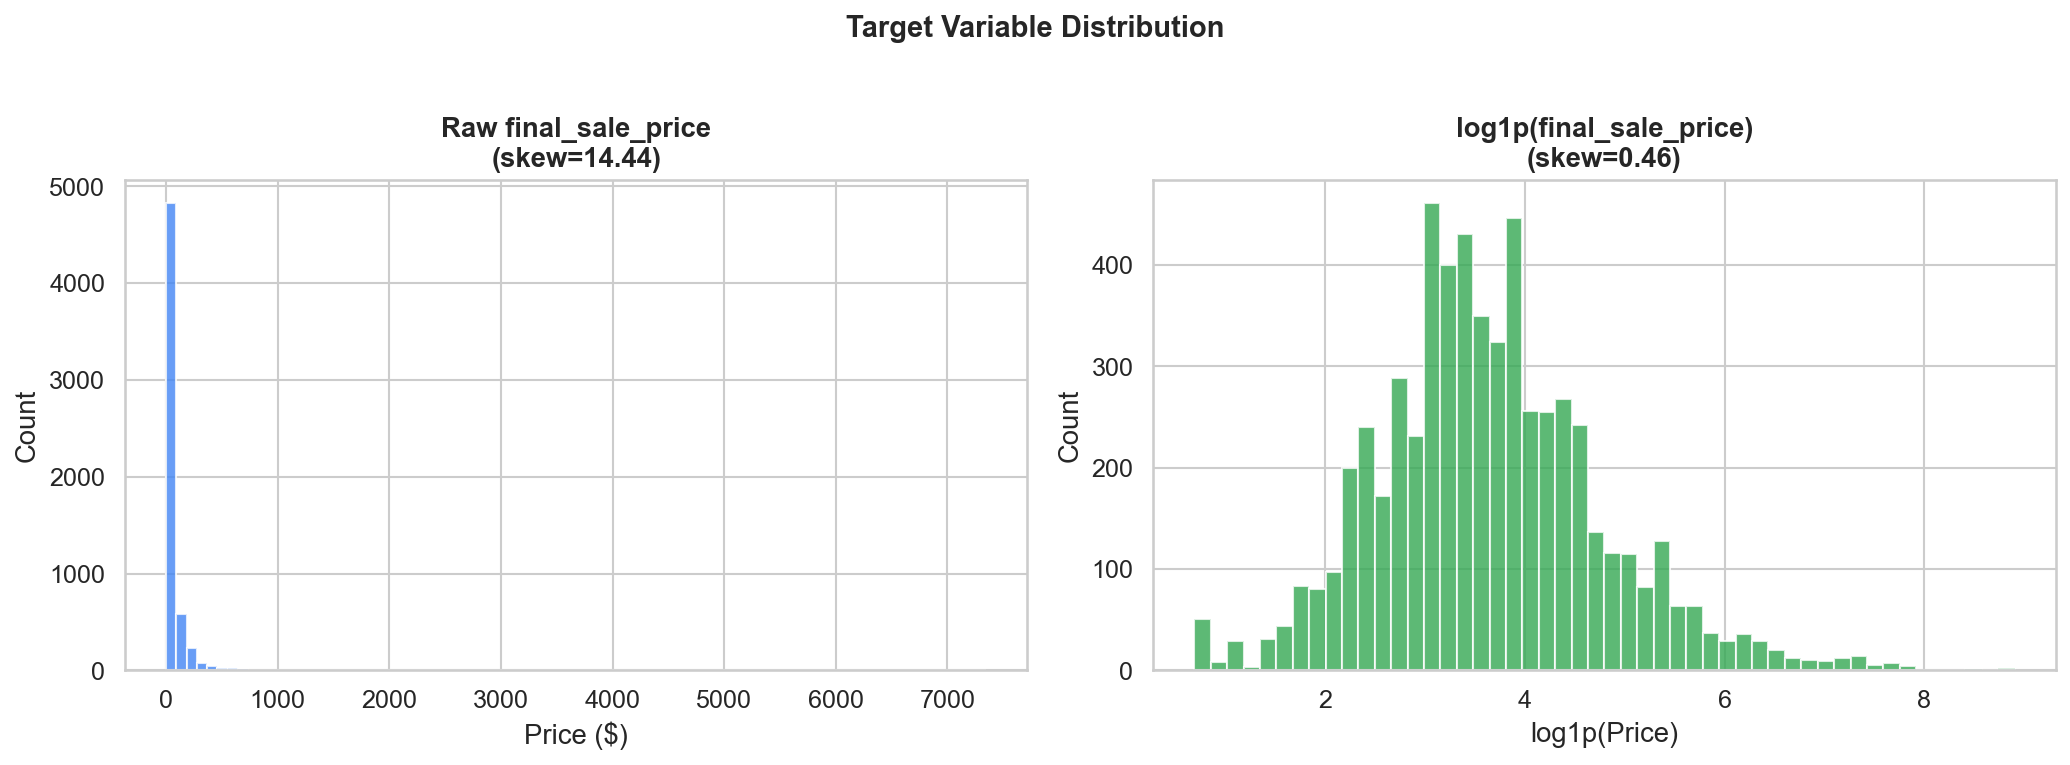

In [3]:
# Target distribution: raw vs log-transformed
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["final_sale_price"], bins=80, color="#4285F4", edgecolor="white", alpha=0.8)
axes[0].set_title(f"Raw final_sale_price\n(skew={df['final_sale_price'].skew():.2f})", fontweight="bold")
axes[0].set_xlabel("Price ($)")
axes[0].set_ylabel("Count")

log_prices = np.log1p(df["final_sale_price"])
axes[1].hist(log_prices, bins=50, color="#34A853", edgecolor="white", alpha=0.8)
axes[1].set_title(f"log1p(final_sale_price)\n(skew={log_prices.skew():.2f})", fontweight="bold")
axes[1].set_xlabel("log1p(Price)")
axes[1].set_ylabel("Count")

fig.suptitle("Target Variable Distribution", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
save_fig("target_distribution")

## Section 2: Feature Engineering

### Brand strategy
- **712 unique brands**, 595 with <5 items. Raw one-hot would create a sparse, overfit-prone matrix.
- Solution: two-level encoding:
  - `brand_tier` (4 levels): luxury / premium / known / unknown — captures the price signal from brand prestige
  - `brand_top30` (31 levels): top 30 brands individually + "Other" — fine-grained signal for high-frequency brands

### Condition strategy
- 30% of rows are "Unknown" condition. This is an honest signal (sellers who don't specify tend to have lower-value items, median $28 vs Good's $34).
- Keep "Unknown" as its own category + ordinal encoding.

### Title features
- Cheap, interpretable features extracted from title text. No TF-IDF (overkill for 5,919 rows with tree models).

In [4]:
# --- Feature engineering constants ---
# Determined from data exploration: brands with median price > $120 and 5+ items
LUXURY_BRANDS = {
    "Chanel", "CHANEL", "Louis Vuitton", "Saint Laurent", "Gucci",
    "Prada", "Balenciaga", "Dior", "Burberry", "Bottega Veneta",
    "Salvatore Ferragamo", "Bed Stu",
}

# Brands with median price $60-$120 and 10+ items
PREMIUM_BRANDS = {
    "Tory Burch", "Coach", "Marc Jacobs", "Dooney & Bourke",
    "Jordan", "Brooks", "Disney", "Off-White", "Air Jordan",
}

# Top 30 brands by count (each 25+ items)
TOP_30_BRANDS = {
    "Nike", "Coach", "Levi's", "Ralph Lauren", "Adidas",
    "Louis Vuitton", "Jordan", "Zara", "Air Jordan", "Michael Kors",
    "Disney", "New Balance", "Harley-Davidson", "Old Navy",
    "Calvin Klein", "Kate Spade", "Anthropologie", "Banana Republic",
    "Vans", "Tory Burch", "Talbots", "Lululemon", "Brooks",
    "Steve Madden", "Free People", "Prada", "Vera Bradley",
    "Converse", "Chanel",
}

CONDITION_MAP = {"Unknown": 0, "Good": 1, "Like New": 2, "New": 3}

SIZE_PATTERN = re.compile(
    r"\b(XXS|XS|S|M|L|XL|XXL|XXXL|\d{1,2}(\.\d)?)\b", re.IGNORECASE
)
NWT_PATTERN = re.compile(r"\b(NWT|BNWT|new with tags)\b", re.IGNORECASE)

In [5]:
def engineer_features(df):
    """Build all modeling features. Reusable for inference in predict_price()."""
    out = df.copy()

    # --- Brand features ---
    out["brand"] = out["brand"].fillna("Unknown")

    # Brand tier
    def get_brand_tier(b):
        if b in LUXURY_BRANDS:
            return "luxury"
        if b in PREMIUM_BRANDS:
            return "premium"
        if b != "Unknown":
            return "known"
        return "unknown"

    out["brand_tier"] = out["brand"].apply(get_brand_tier)

    # Top 30 brands (individual encoding)
    out["brand_top30"] = out["brand"].apply(lambda b: b if b in TOP_30_BRANDS else "Other")

    # --- Condition features ---
    out["condition"] = out["condition"].fillna("Unknown")
    out["condition_ordinal"] = out["condition"].map(CONDITION_MAP).fillna(0).astype(int)

    # --- Title features ---
    title_lower = out["title"].str.lower()
    out["title_length"] = out["title"].str.len()
    out["title_word_count"] = out["title"].str.split().str.len()
    out["title_has_brand"] = (
        (out["brand"] != "Unknown")
        & out.apply(lambda r: r["brand"].lower() in r["title"].lower(), axis=1)
    ).astype(int)
    out["title_has_size"] = title_lower.str.contains(SIZE_PATTERN).astype(int)
    out["title_has_vintage"] = title_lower.str.contains("vintage").astype(int)
    out["title_has_nwt"] = title_lower.str.contains(NWT_PATTERN).astype(int)

    # --- Interaction features ---
    out["platform_category"] = out["platform"] + "_" + out["item_category"]

    return out


df = engineer_features(df)
print(f"Features engineered. Shape: {df.shape}")
print(f"\nbrand_tier distribution:\n{df['brand_tier'].value_counts().to_string()}")
print(f"\ncondition_ordinal distribution:\n{df['condition_ordinal'].value_counts().sort_index().to_string()}")

Features engineered. Shape: (5919, 16)

brand_tier distribution:
brand_tier
known      2683
unknown    2589
premium     416
luxury      231

condition_ordinal distribution:
condition_ordinal
0    1791
1    2700
2     458
3     970


/var/folders/1g/s1pb0hwn635bghf2np2hjf8h0000gn/T/ipykernel_81134/2914593327.py:35: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  out["title_has_size"] = title_lower.str.contains(SIZE_PATTERN).astype(int)
/var/folders/1g/s1pb0hwn635bghf2np2hjf8h0000gn/T/ipykernel_81134/2914593327.py:37: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  out["title_has_nwt"] = title_lower.str.contains(NWT_PATTERN).astype(int)


## Section 3: Train/Test Split

80/20 split, stratified by `platform × item_category` (24 strata) to ensure every platform-category combination appears proportionally in both sets.

In [6]:
# Define feature columns
CATEGORICAL_FEATURES = ["platform", "item_category", "brand_tier", "brand_top30",
                         "condition", "platform_category"]
NUMERIC_FEATURES = ["condition_ordinal", "title_length", "title_word_count",
                     "title_has_brand", "title_has_size", "title_has_vintage",
                     "title_has_nwt"]
ALL_FEATURES = CATEGORICAL_FEATURES + NUMERIC_FEATURES

TARGET = "final_sale_price"

# Stratified split
strat_key = df["platform"] + "_" + df["item_category"]
X = df[ALL_FEATURES]
y_raw = df[TARGET]
y_log = np.log1p(y_raw)

X_train, X_test, y_train_raw, y_test_raw = train_test_split(
    X, y_raw, test_size=0.2, random_state=42, stratify=strat_key
)
y_train_log = np.log1p(y_train_raw)
y_test_log = np.log1p(y_test_raw)

print(f"Train: {len(X_train)} rows | Test: {len(X_test)} rows")
print(f"\n--- Train set by platform ---")
print(X_train["platform"].value_counts().to_string())
print(f"\n--- Test set by platform ---")
print(X_test["platform"].value_counts().to_string())

Train: 4735 rows | Test: 1184 rows

--- Train set by platform ---
platform
eBay        3128
Poshmark     952
Depop        655

--- Test set by platform ---
platform
eBay        782
Poshmark    238
Depop       164


## Section 4: Baseline Model

Predict the `median(final_sale_price)` per `platform × item_category` group, computed on the training set only. This is the "no model" floor — any real model must beat this.

In [7]:
# Baseline: group median from training set
train_with_target = X_train.copy()
train_with_target["final_sale_price"] = y_train_raw.values

group_medians = train_with_target.groupby(["platform", "item_category"])["final_sale_price"].median()

# Predict on test set
baseline_preds = X_test.apply(
    lambda r: group_medians.get((r["platform"], r["item_category"]), y_train_raw.median()),
    axis=1,
)

# Evaluate
def eval_model(y_true, y_pred, label=""):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = median_ape(y_true, y_pred)
    print(f"{label:25s}  MAE: ${mae:8.2f}  |  RMSE: ${rmse:8.2f}  |  MedAPE: {mape:5.1f}%")
    return {"MAE": mae, "RMSE": rmse, "MedAPE": mape}

results = {}
print("=== Model Comparison (test set, dollar scale) ===\n")
results["Baseline (group median)"] = eval_model(y_test_raw, baseline_preds, "Baseline (group median)")

=== Model Comparison (test set, dollar scale) ===

Baseline (group median)    MAE: $   61.17  |  RMSE: $  182.38  |  MedAPE:  57.0%


## Section 5: Ridge Regression (linear benchmark)

In [8]:
# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL_FEATURES),
        ("num", "passthrough", NUMERIC_FEATURES),
    ]
)

# Ridge on log1p target
ridge_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0)),
])

ridge_pipe.fit(X_train, y_train_log)
ridge_preds_log = ridge_pipe.predict(X_test)
ridge_preds = np.clip(np.expm1(ridge_preds_log), 1.0, None)

results["Ridge"] = eval_model(y_test_raw, ridge_preds, "Ridge")

Ridge                      MAE: $   54.16  |  RMSE: $  158.29  |  MedAPE:  51.1%


## Section 6: XGBoost (primary model)

### 6a. Default XGBoost → 6b. Hyperparameter tuning → 6c. Feature importance

In [9]:
# 6a. Default XGBoost
xgb_default_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=500,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        n_jobs=-1,
    )),
])

xgb_default_pipe.fit(X_train, y_train_log)
xgb_default_preds_log = xgb_default_pipe.predict(X_test)
xgb_default_preds = np.clip(np.expm1(xgb_default_preds_log), 1.0, None)

results["XGBoost (default)"] = eval_model(y_test_raw, xgb_default_preds, "XGBoost (default)")

XGBoost (default)          MAE: $   57.48  |  RMSE: $  161.99  |  MedAPE:  55.1%


In [10]:
# 6b. Hyperparameter tuning via GridSearchCV
param_grid = {
    "model__max_depth": [4, 6, 8],
    "model__learning_rate": [0.05, 0.1],
    "model__n_estimators": [300, 500, 800],
    "model__min_child_weight": [3, 5, 10],
    "model__subsample": [0.8, 1.0],
}

xgb_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", xgb.XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
    )),
])

grid_search = GridSearchCV(
    xgb_pipe,
    param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=0,
)

grid_search.fit(X_train, y_train_log)

print(f"Best params: {grid_search.best_params_}")
print(f"Best CV MAE (log scale): {-grid_search.best_score_:.4f}")

Best params: {'model__learning_rate': 0.05, 'model__max_depth': 4, 'model__min_child_weight': 5, 'model__n_estimators': 300, 'model__subsample': 1.0}
Best CV MAE (log scale): 0.7028


In [11]:
# Evaluate tuned XGBoost on test set
best_model = grid_search.best_estimator_
xgb_tuned_preds_log = best_model.predict(X_test)
xgb_tuned_preds = np.clip(np.expm1(xgb_tuned_preds_log), 1.0, None)

results["XGBoost (tuned)"] = eval_model(y_test_raw, xgb_tuned_preds, "XGBoost (tuned)")

print(f"\n--- Improvement over baseline ---")
baseline_mae = results["Baseline (group median)"]["MAE"]
tuned_mae = results["XGBoost (tuned)"]["MAE"]
print(f"Baseline MAE: ${baseline_mae:.2f}")
print(f"XGBoost MAE:  ${tuned_mae:.2f}")
print(f"Improvement:  ${baseline_mae - tuned_mae:.2f} ({(baseline_mae - tuned_mae) / baseline_mae * 100:.1f}%)")

XGBoost (tuned)            MAE: $   52.79  |  RMSE: $  151.16  |  MedAPE:  50.2%

--- Improvement over baseline ---
Baseline MAE: $61.17
XGBoost MAE:  $52.79
Improvement:  $8.37 (13.7%)


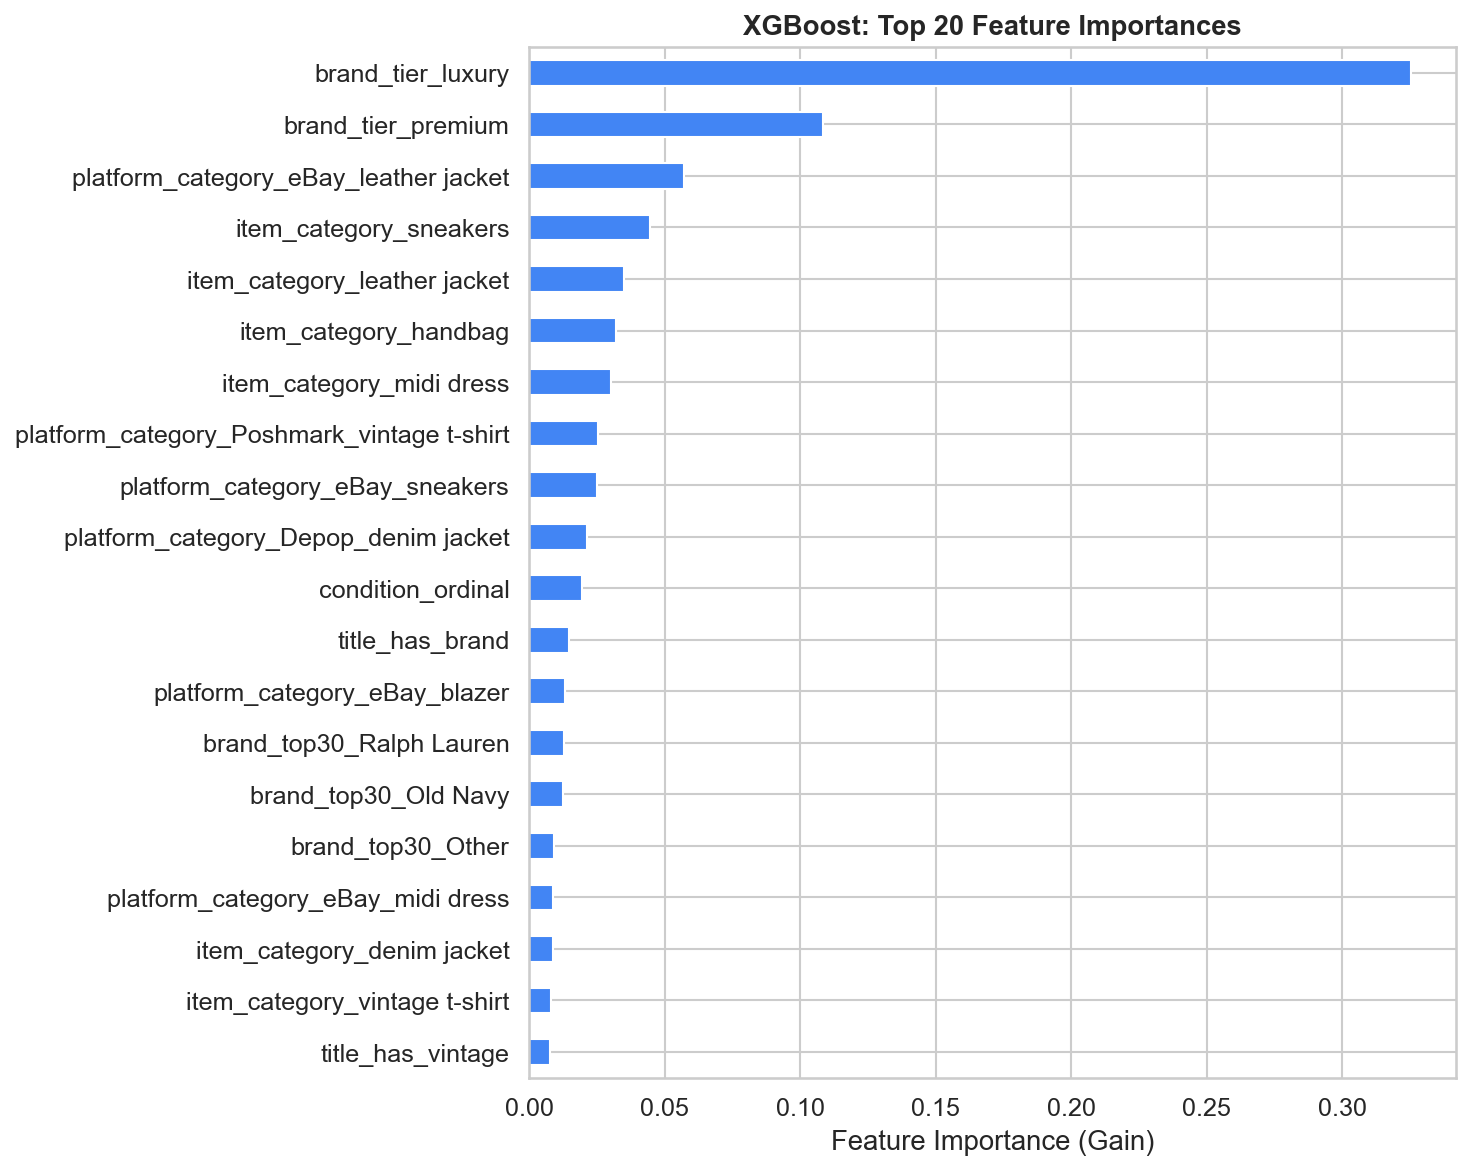

In [12]:
# 6c. Feature importance (top 20)
xgb_model = best_model.named_steps["model"]
ohe = best_model.named_steps["preprocessor"].named_transformers_["cat"]
cat_feature_names = list(ohe.get_feature_names_out(CATEGORICAL_FEATURES))
all_feature_names = cat_feature_names + NUMERIC_FEATURES

importances = pd.Series(xgb_model.feature_importances_, index=all_feature_names)
top20 = importances.nlargest(20)

fig, ax = plt.subplots(figsize=(10, 8))
top20.sort_values().plot.barh(ax=ax, color="#4285F4", edgecolor="white")
ax.set_xlabel("Feature Importance (Gain)")
ax.set_title("XGBoost: Top 20 Feature Importances", fontweight="bold")
fig.tight_layout()
save_fig("feature_importance")

## Section 7: Comprehensive Evaluation

### 7a. Overall metrics | 7b. Per-platform parity | 7c. Per-price-tier | 7d. Visualizations

In [13]:
# 7a. Overall metrics summary
print("=" * 75)
print("  OVERALL MODEL COMPARISON (test set)")
print("=" * 75)
print()
print(f"{'Model':25s}  {'MAE ($)':>10s}  |  {'RMSE ($)':>10s}  |  {'MedAPE':>8s}")
print("-" * 75)
for name, m in results.items():
    print(f"{name:25s}  ${m['MAE']:8.2f}    |  ${m['RMSE']:8.2f}    |  {m['MedAPE']:5.1f}%")

  OVERALL MODEL COMPARISON (test set)

Model                         MAE ($)  |    RMSE ($)  |    MedAPE
---------------------------------------------------------------------------
Baseline (group median)    $   61.17    |  $  182.38    |   57.0%
Ridge                      $   54.16    |  $  158.29    |   51.1%
XGBoost (default)          $   57.48    |  $  161.99    |   55.1%
XGBoost (tuned)            $   52.79    |  $  151.16    |   50.2%


In [14]:
# 7b. Per-platform parity analysis
print("=" * 75)
print("  PER-PLATFORM PARITY (XGBoost tuned, test set)")
print("=" * 75)

test_eval = X_test.copy()
test_eval["y_true"] = y_test_raw.values
test_eval["y_pred"] = xgb_tuned_preds

platform_metrics = {}
for plat in ["eBay", "Poshmark", "Depop"]:
    mask = test_eval["platform"] == plat
    sub = test_eval[mask]
    if len(sub) == 0:
        continue
    mae = mean_absolute_error(sub["y_true"], sub["y_pred"])
    rmse = np.sqrt(mean_squared_error(sub["y_true"], sub["y_pred"]))
    mape = median_ape(sub["y_true"].values, sub["y_pred"].values)
    platform_metrics[plat] = {"MAE": mae, "RMSE": rmse, "MedAPE": mape, "n": len(sub)}
    caveat = " (listed price proxy)" if plat == "Depop" else ""
    print(f"\n  {plat}{caveat}  (n={len(sub)})")
    print(f"    MAE:    ${mae:.2f}")
    print(f"    RMSE:   ${rmse:.2f}")
    print(f"    MedAPE: {mape:.1f}%")

# Parity assessment
ebay_mae = platform_metrics["eBay"]["MAE"]
posh_mae = platform_metrics["Poshmark"]["MAE"]
depop_mae = platform_metrics["Depop"]["MAE"]

print(f"\n--- Platform Parity Assessment ---")
print(f"  eBay MAE:     ${ebay_mae:.2f} (n={platform_metrics['eBay']['n']})")
print(f"  Poshmark MAE: ${posh_mae:.2f} (n={platform_metrics['Poshmark']['n']})")
print(f"  Depop MAE:    ${depop_mae:.2f} (n={platform_metrics['Depop']['n']}, listed price proxy)")

max_mae = max(ebay_mae, posh_mae, depop_mae)
min_mae = min(ebay_mae, posh_mae, depop_mae)
if max_mae / min_mae > 2:
    print(f"\n  WARNING: MAE spread is {max_mae/min_mae:.1f}x — significant platform disparity.")
    print(f"  The 'works across all 3 platforms' claim needs qualification.")
else:
    print(f"\n  MAE spread is {max_mae/min_mae:.1f}x — reasonable platform parity.")

  PER-PLATFORM PARITY (XGBoost tuned, test set)

  eBay  (n=782)
    MAE:    $60.01
    RMSE:   $172.53
    MedAPE: 50.5%

  Poshmark  (n=238)
    MAE:    $44.20
    RMSE:   $110.15
    MedAPE: 46.0%

  Depop (listed price proxy)  (n=164)
    MAE:    $30.85
    RMSE:   $73.51
    MedAPE: 51.6%

--- Platform Parity Assessment ---
  eBay MAE:     $60.01 (n=782)
  Poshmark MAE: $44.20 (n=238)
  Depop MAE:    $30.85 (n=164, listed price proxy)

  MAE spread is 1.9x — reasonable platform parity.


In [15]:
# 7c. Per-price-tier breakdown
TIER_BINS = [0, 20, 75, 200, np.inf]
TIER_LABELS = ["Budget (<$20)", "Mid ($20-75)", "Premium ($75-200)", "Luxury (>$200)"]

test_eval["price_tier"] = pd.cut(test_eval["y_true"], bins=TIER_BINS, labels=TIER_LABELS)

print("=" * 75)
print("  PER-PRICE-TIER (XGBoost tuned, test set)")
print("=" * 75)

for tier in TIER_LABELS:
    sub = test_eval[test_eval["price_tier"] == tier]
    if len(sub) == 0:
        continue
    mae = mean_absolute_error(sub["y_true"], sub["y_pred"])
    mape = median_ape(sub["y_true"].values, sub["y_pred"].values)
    print(f"\n  {tier}  (n={len(sub)})")
    print(f"    MAE:    ${mae:.2f}")
    print(f"    MedAPE: {mape:.1f}%")

  PER-PRICE-TIER (XGBoost tuned, test set)

  Budget (<$20)  (n=373)
    MAE:    $16.39
    MedAPE: 124.3%

  Mid ($20-75)  (n=530)
    MAE:    $17.15
    MedAPE: 32.0%

  Premium ($75-200)  (n=180)
    MAE:    $72.75
    MedAPE: 55.8%

  Luxury (>$200)  (n=101)
    MAE:    $338.71
    MedAPE: 75.1%


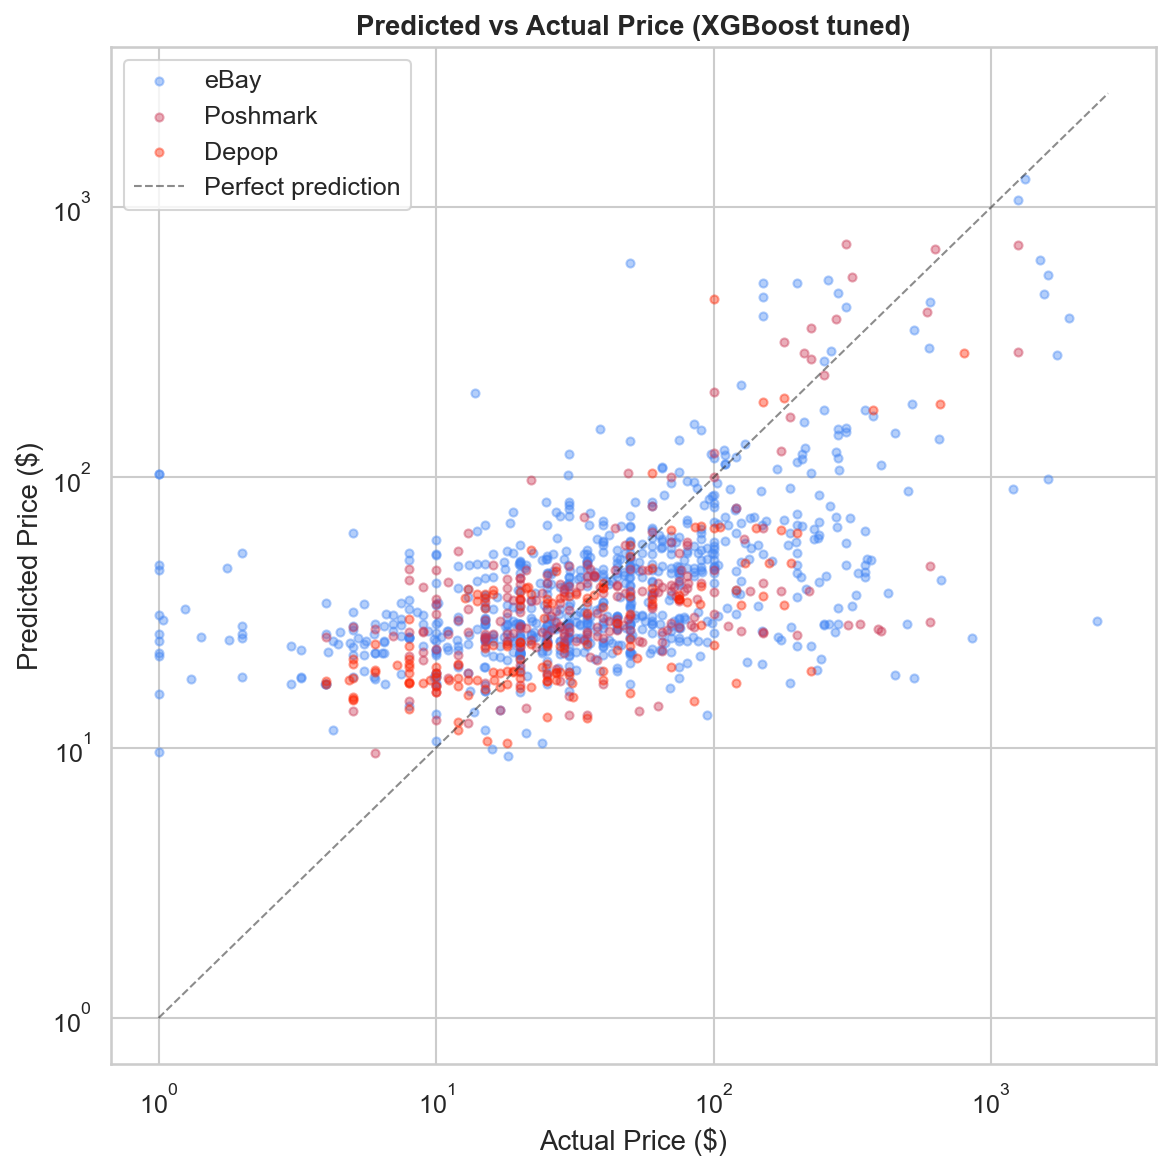

In [16]:
# 7d. Predicted vs actual scatter (log scale)
fig, ax = plt.subplots(figsize=(8, 8))

colors_map = {"eBay": "#4285F4", "Poshmark": "#C83250", "Depop": "#FF2300"}
for plat in ["eBay", "Poshmark", "Depop"]:
    mask = test_eval["platform"] == plat
    ax.scatter(
        test_eval.loc[mask, "y_true"],
        test_eval.loc[mask, "y_pred"],
        alpha=0.4, s=15, label=plat, color=colors_map[plat],
    )

lims = [1, test_eval[["y_true", "y_pred"]].max().max() * 1.1]
ax.plot(lims, lims, "k--", linewidth=1, alpha=0.5, label="Perfect prediction")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Actual Price ($)")
ax.set_ylabel("Predicted Price ($)")
ax.set_title("Predicted vs Actual Price (XGBoost tuned)", fontweight="bold")
ax.legend()
fig.tight_layout()
save_fig("predicted_vs_actual")

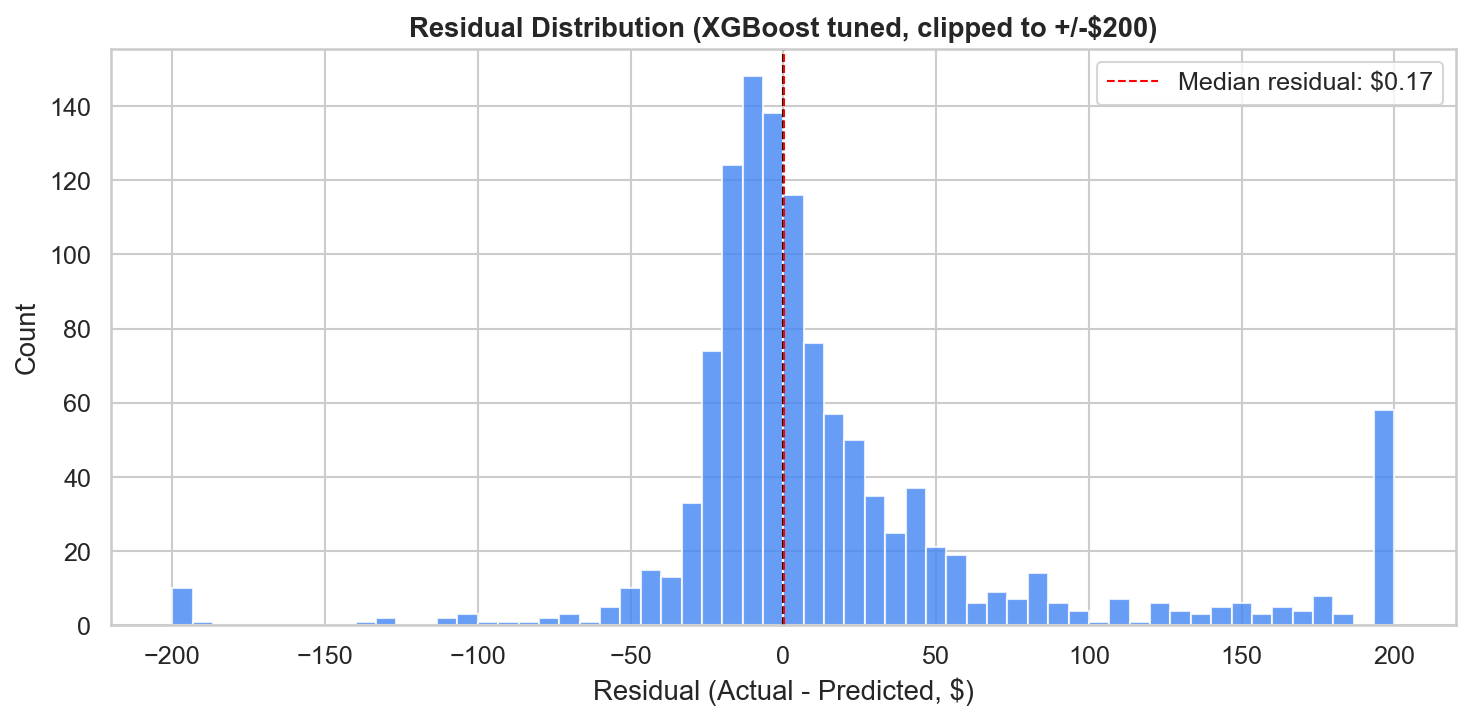

In [17]:
# Residual distribution
residuals = test_eval["y_true"] - test_eval["y_pred"]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(residuals.clip(-200, 200), bins=60, color="#4285F4", edgecolor="white", alpha=0.8)
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.axvline(residuals.median(), color="red", linestyle="--", linewidth=1,
           label=f"Median residual: ${residuals.median():.2f}")
ax.set_xlabel("Residual (Actual - Predicted, $)")
ax.set_ylabel("Count")
ax.set_title("Residual Distribution (XGBoost tuned, clipped to +/-$200)", fontweight="bold")
ax.legend()
fig.tight_layout()
save_fig("residual_distribution")

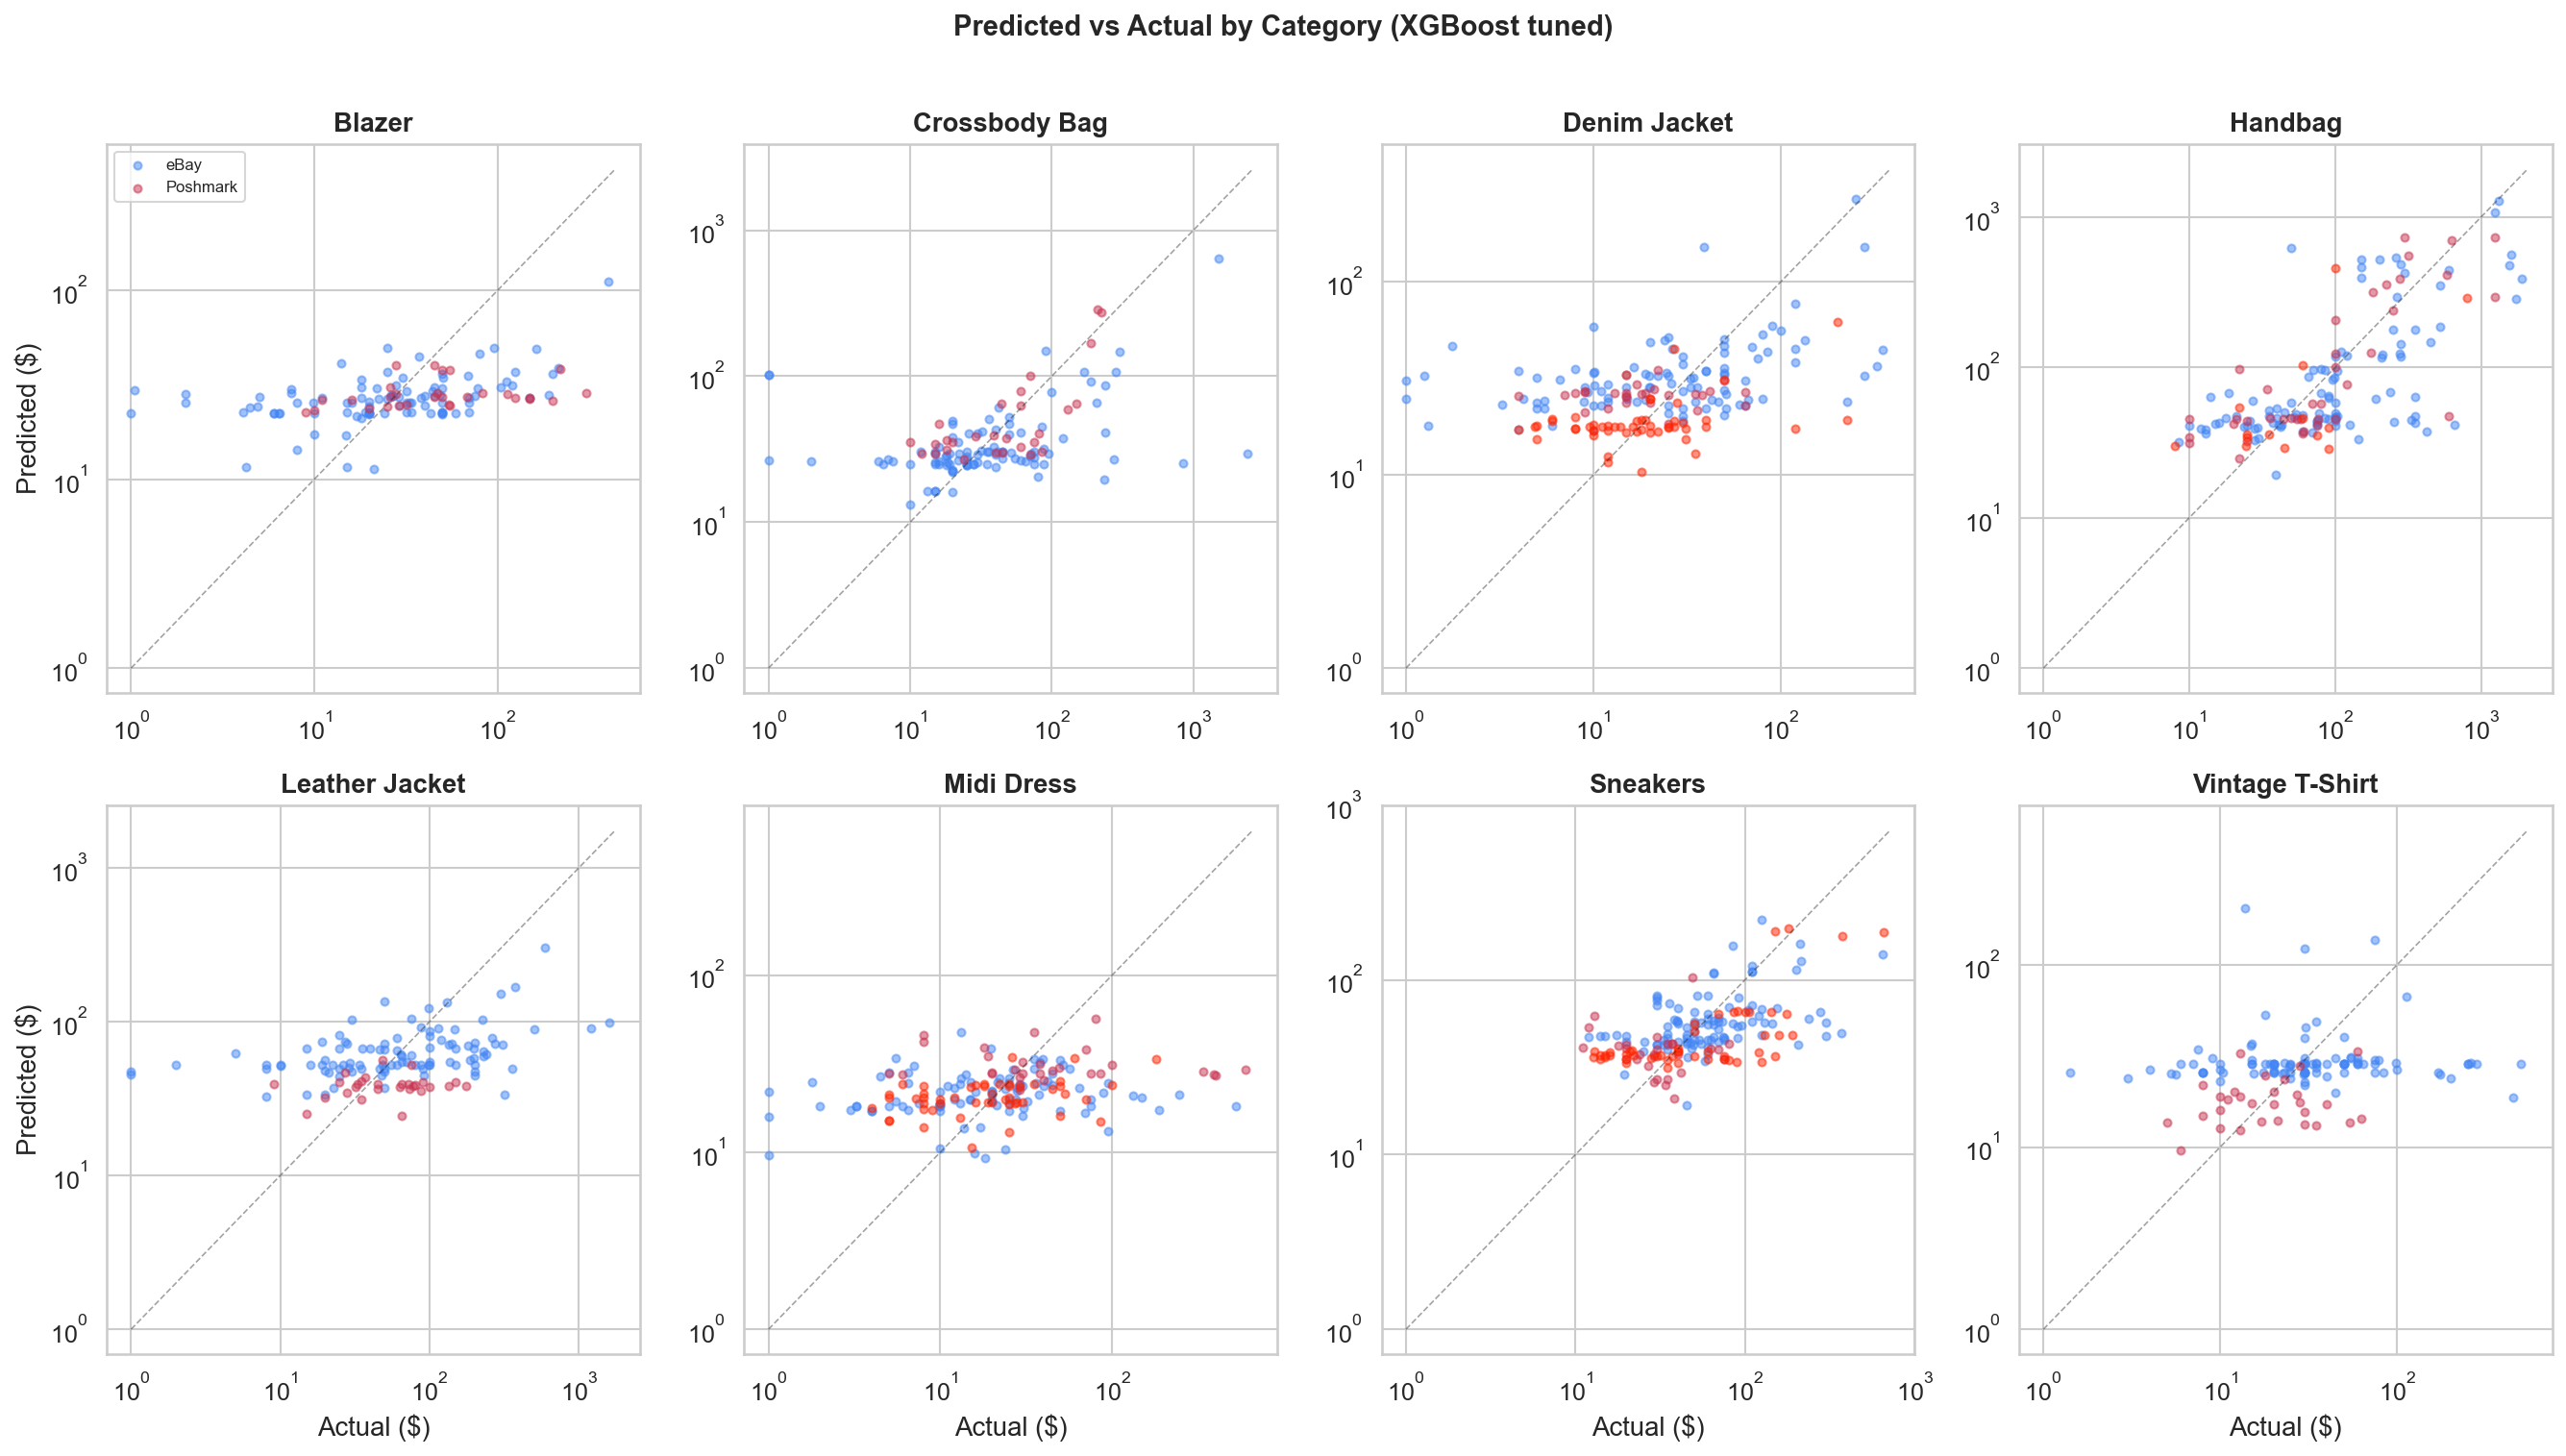

In [18]:
# Per-category predicted vs actual (2x4 grid)
categories = sorted(test_eval["item_category"].unique())
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, cat in enumerate(categories):
    ax = axes[i]
    sub = test_eval[test_eval["item_category"] == cat]
    for plat in ["eBay", "Poshmark", "Depop"]:
        pmask = sub["platform"] == plat
        if pmask.sum() > 0:
            ax.scatter(sub.loc[pmask, "y_true"], sub.loc[pmask, "y_pred"],
                       alpha=0.5, s=15, color=colors_map[plat], label=plat)
    cat_lims = [1, max(sub[["y_true", "y_pred"]].max().max() * 1.1, 10)]
    ax.plot(cat_lims, cat_lims, "k--", linewidth=0.8, alpha=0.4)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(cat.title(), fontweight="bold")
    ax.set_xlabel("Actual ($)" if i >= 4 else "")
    ax.set_ylabel("Predicted ($)" if i % 4 == 0 else "")
    if i == 0:
        ax.legend(fontsize=8)

fig.suptitle("Predicted vs Actual by Category (XGBoost tuned)", fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
save_fig("predicted_vs_actual_by_category")

## Section 8: Model Serialization & Prediction Functions

Save the trained model and feature configuration for use in Sprint 4's routing algorithm.

In [19]:
# Save model and feature config
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(exist_ok=True)

joblib.dump(best_model, MODELS_DIR / "pricing_model.joblib")

feature_config = {
    "LUXURY_BRANDS": LUXURY_BRANDS,
    "PREMIUM_BRANDS": PREMIUM_BRANDS,
    "TOP_30_BRANDS": TOP_30_BRANDS,
    "CONDITION_MAP": CONDITION_MAP,
    "CATEGORICAL_FEATURES": CATEGORICAL_FEATURES,
    "NUMERIC_FEATURES": NUMERIC_FEATURES,
    "ALL_FEATURES": ALL_FEATURES,
}
joblib.dump(feature_config, MODELS_DIR / "feature_config.joblib")

print(f"Model saved to {MODELS_DIR / 'pricing_model.joblib'}")
print(f"Feature config saved to {MODELS_DIR / 'feature_config.joblib'}")

Model saved to ../models/pricing_model.joblib
Feature config saved to ../models/feature_config.joblib


In [20]:
def predict_price(platform: str, item_category: str, brand: str,
                  condition: str, title: str) -> dict:
    """Predict final sale price for an item on a specific platform.
    
    Returns:
        dict with: predicted_price (float), depop_caveat (bool)
    """
    row = pd.DataFrame([{
        "platform": platform,
        "item_category": item_category,
        "brand": brand,
        "condition": condition,
        "title": title,
    }])
    row = engineer_features(row)
    pred_log = best_model.predict(row[ALL_FEATURES])
    pred_price = float(np.clip(np.expm1(pred_log[0]), 1.0, None))
    return {
        "predicted_price": round(pred_price, 2),
        "depop_caveat": platform == "Depop",
    }


def predict_price_all_platforms(item_category: str, brand: str,
                                 condition: str, title: str) -> pd.DataFrame:
    """Predict price across all 3 platforms for the same item.
    
    Returns DataFrame with columns: platform, predicted_price, depop_caveat.
    Core input for Sprint 4's routing algorithm.
    """
    results_list = []
    for plat in ["eBay", "Poshmark", "Depop"]:
        pred = predict_price(plat, item_category, brand, condition, title)
        pred["platform"] = plat
        results_list.append(pred)
    return pd.DataFrame(results_list)[["platform", "predicted_price", "depop_caveat"]]


# Demo: predict price for a Nike sneaker across all platforms
print("=== Demo: predict_price_all_platforms ===\n")
demo = predict_price_all_platforms("sneakers", "Nike", "Good",
                                    "Nike Air Max 90 Men's Size 10 White")
print(demo.to_string(index=False))
print("\nNote: Depop prediction is a listed-price proxy, not a sold-price prediction.")

=== Demo: predict_price_all_platforms ===

platform  predicted_price  depop_caveat
    eBay            42.65         False
Poshmark            32.35         False
   Depop            31.73          True

Note: Depop prediction is a listed-price proxy, not a sold-price prediction.


/var/folders/1g/s1pb0hwn635bghf2np2hjf8h0000gn/T/ipykernel_81134/2914593327.py:35: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  out["title_has_size"] = title_lower.str.contains(SIZE_PATTERN).astype(int)
/var/folders/1g/s1pb0hwn635bghf2np2hjf8h0000gn/T/ipykernel_81134/2914593327.py:37: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  out["title_has_nwt"] = title_lower.str.contains(NWT_PATTERN).astype(int)
/var/folders/1g/s1pb0hwn635bghf2np2hjf8h0000gn/T/ipykernel_81134/2914593327.py:35: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  out["title_has_size"] = title_lower.str.contains(SIZE_PATTERN).astype(int)
/var/folders/1g/s1pb0hwn635bghf2np2hjf8h0000gn/T/ipykernel_81134/2914593327.py:37: UserWarning: This pattern is interpreted

## Section 9: Honest Limitations

1. **Depop = listed prices, not sold prices.** The model predicts what items are *listed* at on Depop, not what they sell for. Depop does not expose sold-price history publicly.

2. **Luxury tail performance.** Items above $200 have high variance and relatively few training examples. Predictions for luxury items should be treated as rough estimates with wide confidence bands.

3. **Brand coverage.** 595 of 712 brands in the dataset have fewer than 5 items and are treated as "unknown." The model's brand signal comes primarily from the top 30 brands and the tier classification. Predictions for rare brands default to category-level patterns.

4. **No temporal features.** Seasonality, trends, and recency are not captured. Depop has no sold dates, and eBay dates come from search-card scraping without listing-date precision.

5. **No photo features.** Item photos, which meaningfully affect resale value through visual condition, styling, and presentation, are not used. This is a known gap for Sprint 4+.

6. **Small dataset.** 5,919 rows across 24 platform-category cells. Some cells are very thin (Depop handbag: 69 items, ~55 in training). Per-cell estimates are fragile at this scale.

7. **Single time snapshot.** The model is trained on a single scrape window. Price dynamics (inflation, seasonal demand, trending items) are not modeled.